# Instituto Tecnológico y de Estudios Superiores de Monterrey
## Escuela de Ingenierías  
## Maestría en Inteligencia Artificial Aplicada  
## Proyecto Integrador (TC5035 - Grupo 10)

---

# Avance 3 – Baseline
## Proyecto Integrador TC5035 – Grupo 28

**Integrantes del grupo:**

- Carolina Gómez Fernández – A01305369  
- Jorge Eduardo Reyes de la Rosa – A00282698  
- Enrique Jiménez Téllez – A01796026  


## Objetivos

**3.1** Establecer las medidas de calidad del modelo de aprendizaje automático.  
**3.2** Proporcionar un marco de referencia para evaluar y mejorar modelos más avanzados.

## Preguntas guía

- ¿Qué algoritmo se puede utilizar como baseline para predecir la variable objetivo?
- ¿Se puede determinar la importancia de las características?
- ¿El modelo está subajustando o sobreajustando los datos de entrenamiento?
- ¿Cuál es la métrica adecuada para este problema?
- ¿Cuál debería ser el desempeño mínimo esperado?


## 0. Configuración inicial e importación de librerías

En esta sección se importan las librerías necesarias para el manejo de datos, entrenamiento de modelos, evaluación de métricas y visualización de resultados.  
También se define la variable objetivo, la semilla aleatoria y parámetros generales para asegurar reproducibilidad.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate, learning_curve
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report
)

# Configuración general
RANDOM_STATE = 42
TARGET = "Target_Reprobado"
pd.set_option("display.max_columns", None)

## 1. Carga de datos

Aquí se monta Google Drive y se cargan los archivos generados en el Avance 2.  
Estos archivos contienen los conjuntos de entrenamiento y prueba ya procesados mediante ingeniería de características.

In [2]:
drive.mount("/content/drive")

# AJUSTAR ESTA RUTA SEGÚN LA CARPETA DONDE ESTÉN LOS ARCHIVOS
ruta_base = "/content/drive/MyDrive/Proyecto Integrador"

train_path = os.path.join(ruta_base, "dataset_train_feature_engineering.csv")
test_path  = os.path.join(ruta_base, "dataset_test_feature_engineering.csv")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Dimensiones del conjunto de entrenamiento:", train_df.shape)
print("Dimensiones del conjunto de prueba:", test_df.shape)
display(train_df.head())

Mounted at /content/drive
Dimensiones del conjunto de entrenamiento: (1192, 16)
Dimensiones del conjunto de prueba: (298, 16)


,Año_lectivo,Promedio de ingreso,Grupo,Evaluación_1,Evaluación_2,Evaluación_3,Tareas_y_Pruebas_Cortas,Promedio_Evaluaciones,Desviacion_Evaluaciones,Diferencia_Eval3_Eval1,Ratio_Tareas_vs_Evaluaciones,Log_Distancia,Nivel_Distancia_Cerca,Nivel_Distancia_Lejos,Nivel_Distancia_Muy_cerca,Target_Reprobado
0,-1.547406,1.815152,-1.529494,-0.271123,-1.300449,0.625233,1.985579,-0.240928,1.193730,0.913813,0.587437,-0.769465,0.0,0.0,1.0,1
1,0.222189,-1.140500,-0.734050,0.365479,0.015388,1.019268,-0.507075,0.641470,0.567877,0.876248,-0.443776,-0.531465,1.0,0.0,0.0,1
2,-0.367676,0.930930,-0.734050,0.458188,-1.095763,0.812711,0.822483,0.172526,1.284042,0.571968,-0.015749,0.378091,0.0,0.0,0.0,1
3,1.401919,-1.447608,-0.336328,-0.716126,0.161592,-0.959205,-0.357686,-0.666482,0.015830,-0.541848,-0.049357,2.333441,0.0,1.0,0.0,1
4,1.401919,2.192338,0.061393,1.539792,1.565151,1.205917,0.472487,1.684493,-0.582136,0.195374,-0.372890,-0.331868,1.0,0.0,0.0,0


## 2. Separación de variables predictoras y variable objetivo

En esta sección se separa `Target_Reprobado` del resto de variables.  
Las variables predictoras se almacenan en `X_train` y `X_test`, mientras que la variable objetivo se almacena en `y_train` y `y_test`.

In [3]:
X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1192, 15)
X_test: (298, 15)
y_train: (1192,)
y_test: (298,)


## 3. Distribución de la variable objetivo

Se revisa la proporción de estudiantes aprobados y reprobados en los conjuntos de entrenamiento y prueba.  
Este análisis permite identificar si existe desbalance de clases y justificar la selección de métricas como F1-Score y Recall.


Distribución de clases en entrenamiento:


,conteo,porcentaje
Target_Reprobado,,
1,658,55.201342
0,534,44.798658



Distribución de clases en prueba:


,conteo,porcentaje
Target_Reprobado,,
1,164,55.033557
0,134,44.966443


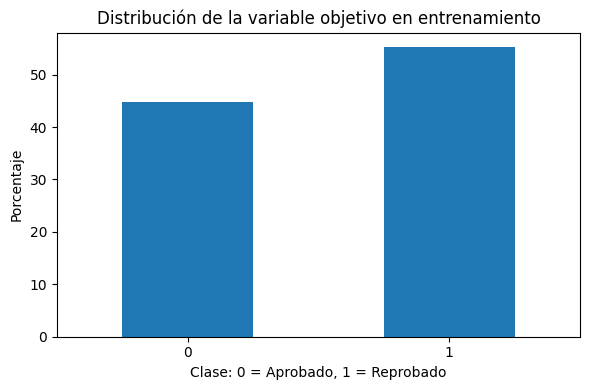

In [4]:
dist_train = y_train.value_counts().to_frame("conteo")
dist_train["porcentaje"] = y_train.value_counts(normalize=True) * 100

dist_test = y_test.value_counts().to_frame("conteo")
dist_test["porcentaje"] = y_test.value_counts(normalize=True) * 100

print("\nDistribución de clases en entrenamiento:")
display(dist_train)

print("\nDistribución de clases en prueba:")
display(dist_test)

plt.figure(figsize=(6, 4))
(y_train.value_counts(normalize=True) * 100).sort_index().plot(kind="bar")
plt.title("Distribución de la variable objetivo en entrenamiento")
plt.xlabel("Clase: 0 = Aprobado, 1 = Reprobado")
plt.ylabel("Porcentaje")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Justificación de métricas

Se define el F1-Score como métrica principal, ya que combina Precision y Recall.  
Esto es importante porque el objetivo del problema es detectar estudiantes en riesgo de reprobar, evitando depender únicamente de Accuracy.

In [5]:
print("""
MÉTRICA PRINCIPAL SELECCIONADA: F1-Score

Justificación:
El problema corresponde a clasificación binaria, donde la clase positiva es Target_Reprobado = 1.
El objetivo de negocio es identificar estudiantes con riesgo de reprobar.

Aunque la distribución de clases no presenta un desbalance severo, se prioriza F1-Score
porque combina Precision y Recall. También se reportan Recall, Precision, Accuracy,
Balanced Accuracy y ROC-AUC para tener una evaluación completa.

Criterios mínimos propuestos para considerar aceptable el baseline:
- F1-Score en prueba >= 0.80
- Recall en prueba >= 0.80
- ROC-AUC en prueba >= 0.85
""")


MÉTRICA PRINCIPAL SELECCIONADA: F1-Score

Justificación:
El problema corresponde a clasificación binaria, donde la clase positiva es Target_Reprobado = 1.
El objetivo de negocio es identificar estudiantes con riesgo de reprobar.

Aunque la distribución de clases no presenta un desbalance severo, se prioriza F1-Score
porque combina Precision y Recall. También se reportan Recall, Precision, Accuracy,
Balanced Accuracy y ROC-AUC para tener una evaluación completa.

Criterios mínimos propuestos para considerar aceptable el baseline:
- F1-Score en prueba >= 0.80
- Recall en prueba >= 0.80
- ROC-AUC en prueba >= 0.85



## 5. Baseline simple: modelo Dummy

Se crea un modelo simple que predice siempre la clase mayoritaria.  
Este resultado sirve como punto mínimo de comparación: cualquier modelo de aprendizaje automático debería superar este desempeño.

In [6]:
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)

baseline_dummy = {
    "Modelo": "Dummy - clase mayoritaria",
    "Accuracy": accuracy_score(y_test, y_pred_dummy),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_dummy),
    "Precision": precision_score(y_test, y_pred_dummy, zero_division=0),
    "Recall": recall_score(y_test, y_pred_dummy, zero_division=0),
    "F1": f1_score(y_test, y_pred_dummy, zero_division=0),
    "ROC-AUC": np.nan
}

print("\nBaseline simple: clase mayoritaria")
display(pd.DataFrame([baseline_dummy]).round(4))


Baseline simple: clase mayoritaria


,Modelo,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC
0,Dummy - clase mayoritaria,0.5503,0.5,0.5503,1.0,0.71,NaN


## 6. Definición de modelos baseline e hiperparámetros

Se definen tres modelos baseline: Regresión Logística, Árbol de Decisión y Random Forest.  
También se establecen rangos de hiperparámetros livianos para evitar tiempos de ejecución excesivos.

In [7]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

modelos_parametros = {
    "Regresión Logística": {
        "modelo": LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),
        "params": {
            "C": [0.1, 1, 10],
            "solver": ["liblinear"]
        }
    },

    "Árbol de Decisión": {
        "modelo": DecisionTreeClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),
        "params": {
            "max_depth": [3, 4, 5, 6],
            "min_samples_leaf": [5, 10, 20]
        }
    },

    "Random Forest": {
        "modelo": RandomForestClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [4, 6, 8],
            "min_samples_leaf": [5, 10]
        }
    }
}

print("""
Modelos seleccionados:
1. Regresión Logística: modelo simple, interpretable y adecuado para clasificación binaria.
2. Árbol de Decisión: permite reglas interpretables y captura relaciones no lineales.
3. Random Forest: modelo de ensamble más robusto, reduce variabilidad y permite importancia de características.
""")


Modelos seleccionados:
1. Regresión Logística: modelo simple, interpretable y adecuado para clasificación binaria.
2. Árbol de Decisión: permite reglas interpretables y captura relaciones no lineales.
3. Random Forest: modelo de ensamble más robusto, reduce variabilidad y permite importancia de características.



## 7. Búsqueda de hiperparámetros

Se utiliza `GridSearchCV` con validación cruzada estratificada para encontrar una configuración adecuada de hiperparámetros.  
La búsqueda se optimiza usando F1-Score como métrica principal.

In [8]:
resultados_grid = []
mejores_modelos = {}

for nombre, config in modelos_parametros.items():
    print("\nBuscando mejores hiperparámetros para:", nombre)

    grid = GridSearchCV(
        estimator=config["modelo"],
        param_grid=config["params"],
        scoring="f1",
        cv=cv,
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)

    mejores_modelos[nombre] = grid.best_estimator_

    resultados_grid.append({
        "Modelo": nombre,
        "Mejor F1 CV": grid.best_score_,
        "Mejores hiperparámetros": grid.best_params_
    })

resultados_grid_df = pd.DataFrame(resultados_grid).sort_values(
    by="Mejor F1 CV",
    ascending=False
)

print("\nResultados de validación cruzada:")
display(resultados_grid_df.round(4))


Buscando mejores hiperparámetros para: Regresión Logística
Fitting 3 folds for each of 3 candidates, totalling 9 fits

Buscando mejores hiperparámetros para: Árbol de Decisión
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Buscando mejores hiperparámetros para: Random Forest
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Resultados de validación cruzada:


,Modelo,Mejor F1 CV,Mejores hiperparámetros
2,Random Forest,0.9205,"{'max_depth': 6, 'min_samples_leaf': 5, 'n_est..."
1,Árbol de Decisión,0.9120,"{'max_depth': 4, 'min_samples_leaf': 5}"
0,Regresión Logística,0.8812,"{'C': 1, 'solver': 'liblinear'}"


## 8. Función general de evaluación

Se define una función reutilizable para entrenar y evaluar cada modelo.  
La función calcula métricas de entrenamiento y prueba, genera reportes de clasificación, matrices de confusión y curvas ROC.

In [10]:
def evaluar_modelo(nombre, modelo, X_train, y_train, X_test, y_test):
    modelo.fit(X_train, y_train)

    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)

    if hasattr(modelo, "predict_proba"):
        y_score_train = modelo.predict_proba(X_train)[:, 1]
        y_score_test = modelo.predict_proba(X_test)[:, 1]
        roc_train = roc_auc_score(y_train, y_score_train)
        roc_test = roc_auc_score(y_test, y_score_test)
    else:
        y_score_test = y_pred_test
        roc_train = np.nan
        roc_test = np.nan

    resultado = {
        "Modelo": nombre,

        "Accuracy Train": accuracy_score(y_train, y_pred_train),
        "Accuracy Test": accuracy_score(y_test, y_pred_test),

        "Balanced Accuracy Train": balanced_accuracy_score(y_train, y_pred_train),
        "Balanced Accuracy Test": balanced_accuracy_score(y_test, y_pred_test),

        "Precision Train": precision_score(y_train, y_pred_train, zero_division=0),
        "Precision Test": precision_score(y_test, y_pred_test, zero_division=0),

        "Recall Train": recall_score(y_train, y_pred_train, zero_division=0),
        "Recall Test": recall_score(y_test, y_pred_test, zero_division=0),

        "F1 Train": f1_score(y_train, y_pred_train, zero_division=0),
        "F1 Test": f1_score(y_test, y_pred_test, zero_division=0),

        "ROC-AUC Train": roc_train,
        "ROC-AUC Test": roc_test,

        "Diferencia F1 Train-Test": (
            f1_score(y_train, y_pred_train, zero_division=0) -
            f1_score(y_test, y_pred_test, zero_division=0)
        )
    }

    print("\n====================================================")
    print(nombre)
    print("====================================================")
    print(classification_report(y_test, y_pred_test, zero_division=0))

    matriz = confusion_matrix(y_test, y_pred_test)
    disp = ConfusionMatrixDisplay(confusion_matrix=matriz)
    disp.plot()
    plt.title("Matriz de confusión - " + nombre)
    plt.tight_layout()
    plt.show()

    if hasattr(modelo, "predict_proba"):
        RocCurveDisplay.from_estimator(modelo, X_test, y_test)
        plt.title("Curva ROC - " + nombre)
        plt.tight_layout()
        plt.show()

    return resultado, modelo

## 9. Entrenamiento y evaluación final

En esta sección se entrenan los mejores modelos encontrados y se comparan sus resultados.  
La comparación permite seleccionar el modelo baseline con mejor desempeño según F1-Score en el conjunto de prueba.


Regresión Logística
              precision    recall  f1-score   support

           0       0.85      0.92      0.88       134
           1       0.93      0.87      0.90       164

    accuracy                           0.89       298
   macro avg       0.89      0.89      0.89       298
weighted avg       0.90      0.89      0.89       298



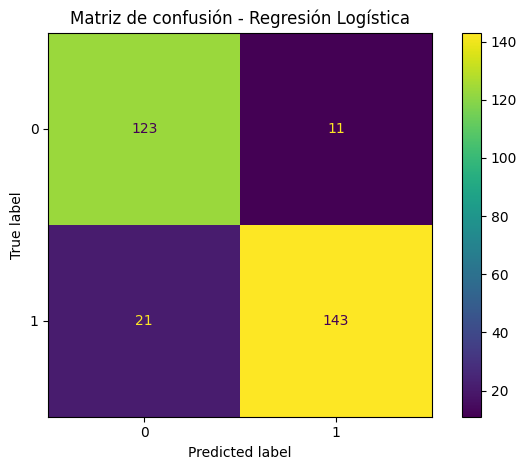

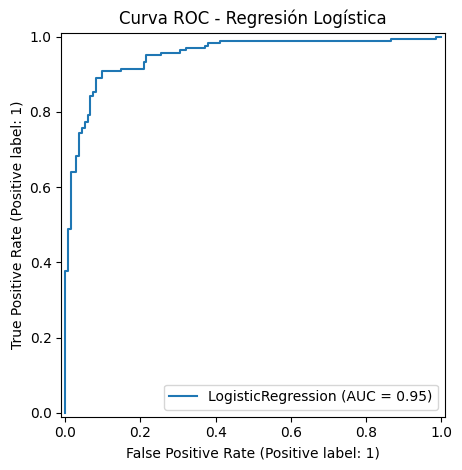


Árbol de Decisión
              precision    recall  f1-score   support

           0       0.86      0.96      0.91       134
           1       0.97      0.87      0.92       164

    accuracy                           0.91       298
   macro avg       0.91      0.92      0.91       298
weighted avg       0.92      0.91      0.91       298



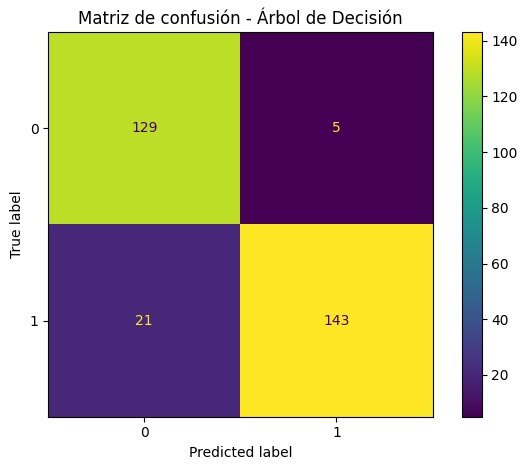

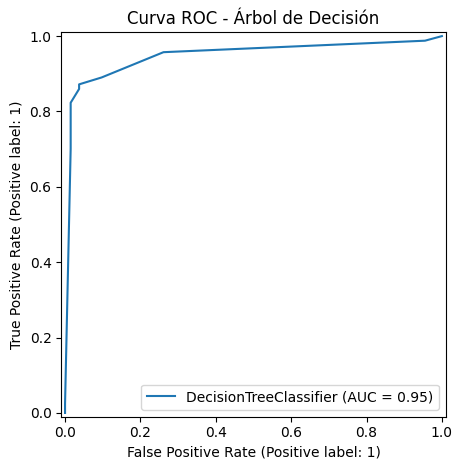


Random Forest
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       134
           1       0.96      0.90      0.93       164

    accuracy                           0.92       298
   macro avg       0.92      0.93      0.92       298
weighted avg       0.93      0.92      0.92       298



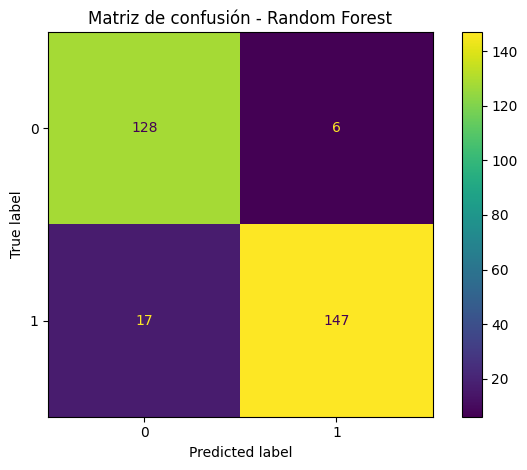

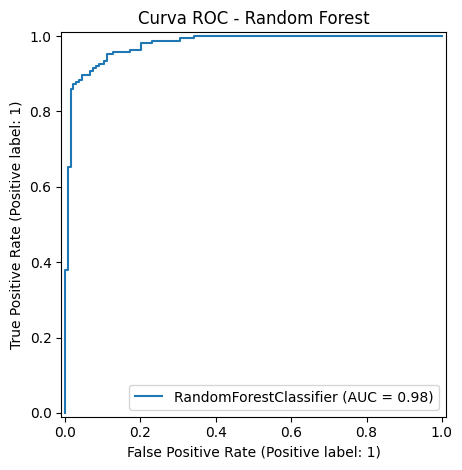


Comparación final de modelos:


,Modelo,Accuracy Train,Accuracy Test,Balanced Accuracy Train,Balanced Accuracy Test,Precision Train,Precision Test,Recall Train,Recall Test,F1 Train,F1 Test,ROC-AUC Train,ROC-AUC Test,Diferencia F1 Train-Test
2,Random Forest,0.9396,0.9228,0.9419,0.9258,0.9696,0.9608,0.9195,0.8963,0.9438,0.9274,0.9880,0.9777,0.0164
1,Árbol de Decisión,0.9203,0.9128,0.9232,0.9173,0.9577,0.9662,0.8951,0.8720,0.9254,0.9167,0.9638,0.9480,0.0087
0,Regresión Logística,0.8758,0.8926,0.8792,0.8949,0.9222,0.9286,0.8465,0.8720,0.8827,0.8994,0.9315,0.9494,-0.0166


In [11]:
resultados = []
modelos_entrenados = {}

for nombre, modelo in mejores_modelos.items():
    resultado, modelo_entrenado = evaluar_modelo(
        nombre,
        modelo,
        X_train,
        y_train,
        X_test,
        y_test
    )

    resultados.append(resultado)
    modelos_entrenados[nombre] = modelo_entrenado

resultados_df = pd.DataFrame(resultados).sort_values(
    by="F1 Test",
    ascending=False
)

print("\nComparación final de modelos:")
display(resultados_df.round(4))

## 10. Análisis de subajuste y sobreajuste

Se comparan las métricas de entrenamiento y prueba.  
Si el rendimiento en entrenamiento es mucho mayor que en prueba, puede existir sobreajuste. Si ambos resultados son bajos, puede existir subajuste.

In [12]:
def interpretar_ajuste(row):
    diferencia = row["Diferencia F1 Train-Test"]

    if row["F1 Train"] < 0.70 and row["F1 Test"] < 0.70:
        return "Posible subajuste: bajo desempeño tanto en entrenamiento como en prueba."
    elif diferencia > 0.10:
        return "Posible sobreajuste: el rendimiento en entrenamiento supera ampliamente al de prueba."
    else:
        return "Ajuste adecuado: métricas de entrenamiento y prueba son cercanas."

ajuste_df = resultados_df[[
    "Modelo",
    "F1 Train",
    "F1 Test",
    "Diferencia F1 Train-Test",
    "Recall Test",
    "ROC-AUC Test"
]].copy()

ajuste_df["Interpretación"] = ajuste_df.apply(interpretar_ajuste, axis=1)

print("\nAnálisis de subajuste / sobreajuste:")
display(ajuste_df.round(4))


Análisis de subajuste / sobreajuste:


,Modelo,F1 Train,F1 Test,Diferencia F1 Train-Test,Recall Test,ROC-AUC Test,Interpretación
2,Random Forest,0.9438,0.9274,0.0164,0.8963,0.9777,Ajuste adecuado: métricas de entrenamiento y p...
1,Árbol de Decisión,0.9254,0.9167,0.0087,0.8720,0.9480,Ajuste adecuado: métricas de entrenamiento y p...
0,Regresión Logística,0.8827,0.8994,-0.0166,0.8720,0.9494,Ajuste adecuado: métricas de entrenamiento y p...


## 11. Selección del mejor modelo baseline

Se identifica el modelo con mejor F1-Score en prueba.  
Este modelo se propone como referencia mínima para comparar modelos más avanzados en etapas posteriores.

In [13]:
mejor_modelo_nombre = resultados_df.iloc[0]["Modelo"]
mejor_modelo = modelos_entrenados[mejor_modelo_nombre]

print("\nMejor modelo baseline según F1-Score en prueba:", mejor_modelo_nombre)
print("F1 Test:", round(resultados_df.iloc[0]["F1 Test"], 4))
print("Recall Test:", round(resultados_df.iloc[0]["Recall Test"], 4))
print("ROC-AUC Test:", round(resultados_df.iloc[0]["ROC-AUC Test"], 4))


Mejor modelo baseline según F1-Score en prueba: Random Forest
F1 Test: 0.9274
Recall Test: 0.8963
ROC-AUC Test: 0.9777


## 12. Importancia de características

Se analiza qué variables tienen mayor influencia en el modelo seleccionado.  
Esto permite interpretar el modelo, reducir variables irrelevantes y cumplir con el criterio de características importantes de la rúbrica.


Importancia de características - Random Forest


,Característica,Importancia
7,Promedio_Evaluaciones,0.3262
5,Evaluación_3,0.1551
4,Evaluación_2,0.1442
3,Evaluación_1,0.0936
6,Tareas_y_Pruebas_Cortas,0.0928
10,Ratio_Tareas_vs_Evaluaciones,0.0596
9,Diferencia_Eval3_Eval1,0.0513
8,Desviacion_Evaluaciones,0.0314
1,Promedio de ingreso,0.0172
0,Año_lectivo,0.0098


<Figure size 900x600 with 0 Axes>

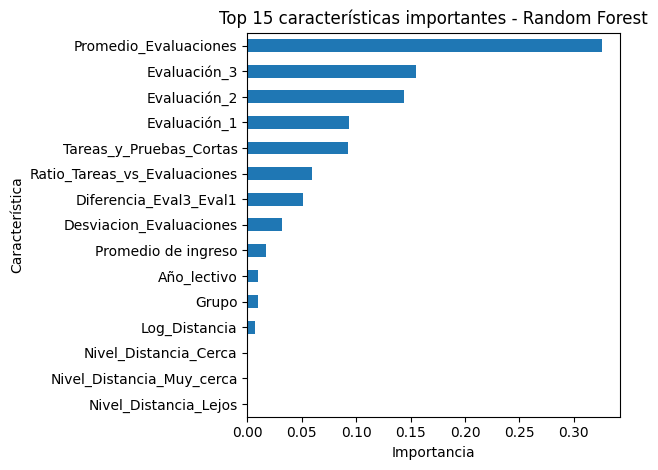

In [14]:
def obtener_importancia(modelo, nombre_modelo, feature_names):
    if hasattr(modelo, "feature_importances_"):
        importancia = modelo.feature_importances_
    elif hasattr(modelo, "coef_"):
        importancia = np.abs(modelo.coef_[0])
    else:
        print("El modelo no permite extraer importancia de características.")
        return None

    importancia_df = pd.DataFrame({
        "Característica": feature_names,
        "Importancia": importancia
    }).sort_values(by="Importancia", ascending=False)

    print("\nImportancia de características -", nombre_modelo)
    display(importancia_df.head(15).round(4))

    plt.figure(figsize=(9, 6))
    importancia_df.head(15).sort_values("Importancia").plot(
        kind="barh",
        x="Característica",
        y="Importancia",
        legend=False
    )
    plt.title("Top 15 características importantes - " + nombre_modelo)
    plt.xlabel("Importancia")
    plt.ylabel("Característica")
    plt.tight_layout()
    plt.show()

    return importancia_df

importancia_mejor_modelo = obtener_importancia(
    mejor_modelo,
    mejor_modelo_nombre,
    X_train.columns
)

## 13. Curvas de aprendizaje

Las curvas de aprendizaje ayudan a observar si el modelo mejora al aumentar la cantidad de datos de entrenamiento.  
También permiten complementar el análisis de subajuste y sobreajuste.

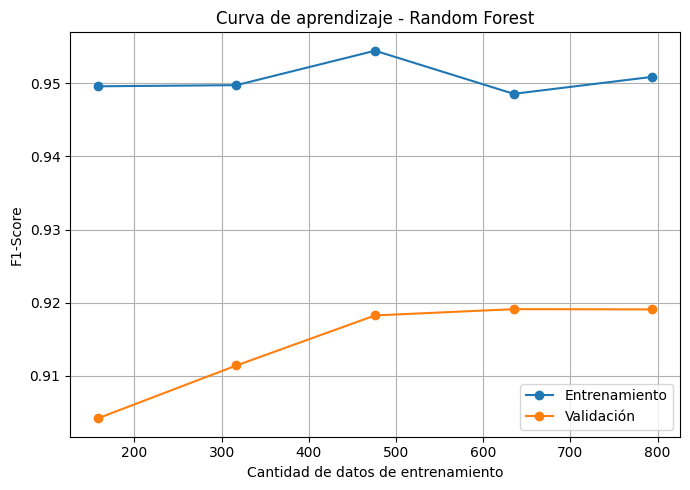

In [15]:
def graficar_curva_aprendizaje(nombre, modelo, X, y):
    train_sizes, train_scores, val_scores = learning_curve(
        modelo,
        X,
        y,
        cv=cv,
        scoring="f1",
        n_jobs=-1,
        train_sizes=np.linspace(0.2, 1.0, 5)
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    plt.figure(figsize=(7, 5))
    plt.plot(train_sizes, train_mean, marker="o", label="Entrenamiento")
    plt.plot(train_sizes, val_mean, marker="o", label="Validación")
    plt.title("Curva de aprendizaje - " + nombre)
    plt.xlabel("Cantidad de datos de entrenamiento")
    plt.ylabel("F1-Score")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

graficar_curva_aprendizaje(mejor_modelo_nombre, mejor_modelo, X_train, y_train)

## 14. Conclusiones automáticas para el informe

Se generan conclusiones breves a partir de los resultados obtenidos.  
Estas conclusiones pueden utilizarse como base para redactar el análisis del Avance 3.

In [16]:
print("\nCONCLUSIONES PARA EL AVANCE 3")
print("====================================================")
print(f"El mejor modelo baseline fue: {mejor_modelo_nombre}.")
print(f"Este modelo obtuvo un F1-Score de prueba de {resultados_df.iloc[0]['F1 Test']:.4f}.")
print(f"El Recall de prueba fue {resultados_df.iloc[0]['Recall Test']:.4f}, lo cual es relevante porque el objetivo es detectar estudiantes con riesgo de reprobar.")
print(f"El ROC-AUC de prueba fue {resultados_df.iloc[0]['ROC-AUC Test']:.4f}, indicando capacidad de separación entre estudiantes aprobados y reprobados.")

if resultados_df.iloc[0]["F1 Test"] >= 0.80 and resultados_df.iloc[0]["Recall Test"] >= 0.80:
    print("El modelo supera el desempeño mínimo esperado, por lo que puede usarse como marco de referencia para modelos más avanzados.")
else:
    print("El modelo no alcanza el desempeño mínimo esperado, por lo que se recomienda revisar variables, calidad de datos o nuevas técnicas de modelado.")

print("""
Este script cumple con la rúbrica porque:
1. Justifica los algoritmos seleccionados según el tipo de problema.
2. Evalúa la importancia de características.
3. Compara métricas de entrenamiento y prueba para detectar sub/sobreajuste.
4. Define F1-Score como métrica principal y reporta métricas complementarias.
5. Establece un desempeño mínimo esperado para valorar si el baseline es aceptable.
""")


CONCLUSIONES PARA EL AVANCE 3
El mejor modelo baseline fue: Random Forest.
Este modelo obtuvo un F1-Score de prueba de 0.9274.
El Recall de prueba fue 0.8963, lo cual es relevante porque el objetivo es detectar estudiantes con riesgo de reprobar.
El ROC-AUC de prueba fue 0.9777, indicando capacidad de separación entre estudiantes aprobados y reprobados.
El modelo supera el desempeño mínimo esperado, por lo que puede usarse como marco de referencia para modelos más avanzados.

Este script cumple con la rúbrica porque:
1. Justifica los algoritmos seleccionados según el tipo de problema.
2. Evalúa la importancia de características.
3. Compara métricas de entrenamiento y prueba para detectar sub/sobreajuste.
4. Define F1-Score como métrica principal y reporta métricas complementarias.
5. Establece un desempeño mínimo esperado para valorar si el baseline es aceptable.

